Simple notebook to show some basic RNN usage

With a 1d heat equation

In [26]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve

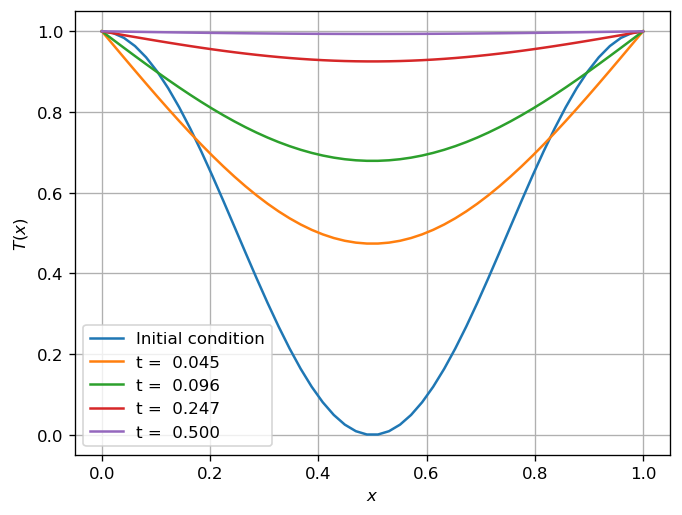

In [27]:
# heat equation in 1d: du/dt = d^2u/dt^2 
# boundary conditions:  T = 1 at x = 0 and x = 1 for all t
Nx = 50
x, dx = np.linspace(0, 1, Nx, retstep = True)
initial_temp = np.cos(np.pi*x)**2# some simple initial temperature that respects the boundary conditions
solutions = [initial_temp] # store the initial condition as the solution at t = 0
Nt = 100
t_end = 0.5
times, dt = np.linspace(0, t_end, Nt, retstep = True)
D2 = diags([1, -2, 1], offsets=[-1, 0, 1], shape=(Nx, Nx), format='csr') / dx**2 # second derivative matrix
A = eye(Nx, format='csr') - dt * D2 # matrix for equation to be solved in implicit Euler
# enforce the boundary conditions directly in the matrix
A = A.tolil()
A[0, :] = 0;  A[0, 0] = 1; A[-1, :] = 0; A[-1, -1] = 1
A = A.tocsr()

# now let the system evolve. if we use explicit Euler for stability we need the CFL condition 
# so to get around this issue we use implicit Euler
for k in range(Nt):
    solutions.append(spsolve(A, solutions[-1]))

# plot 
plt.figure(dpi = 120)
plt.plot(x, initial_temp, label = "Initial condition")
plt.plot(x, solutions[int(Nt/10)], label = f"t =  {times[int(Nt/10)-1]:.3f}")
plt.plot(x, solutions[int(Nt/5)], label = f"t =  {times[int(Nt/5)-1]:.3f}")
plt.plot(x, solutions[int(Nt/2)], label = f"t =  {times[int(Nt/2)-1]:.3f}")
plt.plot(x, solutions[int(Nt)], label = f"t =  {times[int(Nt)-1]:.3f}")
plt.grid()
plt.xlabel("$x$")
plt.ylabel("$T(x)$")
plt.legend()
plt.show()

In [28]:
# now apply an RNN to the solutions  
# first, format the data for the RNN
window_size = 12

solution_intervals = [] # ensemble of the solution vectors 
targets = [] # the solution to be predicted, i.e. the one after each window

for i in range(Nt - window_size):
    solution_intervals.append(solutions[i:i+window_size])
    targets.append(solutions[i + window_size])  # what we want to predict

# Convert to PyTorch tensors with shapes: (Batch, Seq_Len, Features)
# use unsqueeze so that the RNN sees each time values as a vector of size 1 (and not as a scalar)
solution_intervals_tensor = torch.tensor(np.array(solution_intervals), dtype=torch.float32)
targets_tensor            = torch.tensor(np.array(targets), dtype=torch.float32)

Epoch [50/200], Loss: 0.002174
Epoch [100/200], Loss: 0.000050
Epoch [150/200], Loss: 0.000092
Epoch [200/200], Loss: 0.000007


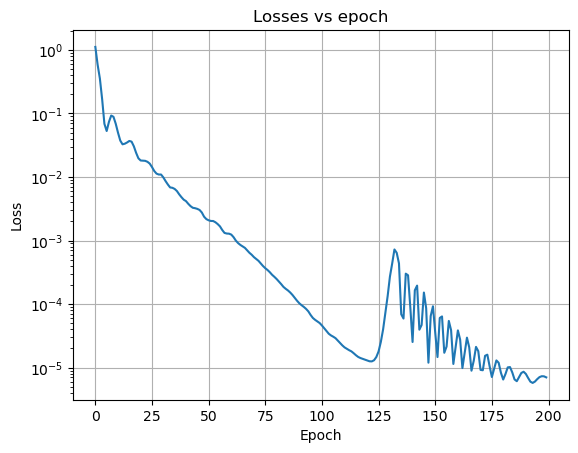

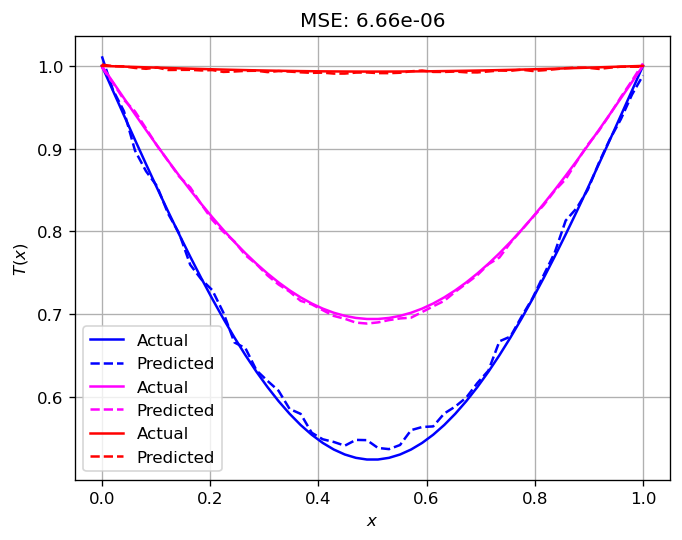

In [29]:
# Then define a simple RNN model
# nn.RNN. 
# hidden state at time t: ht = tanh(x Wih + bih + h_(t-1)W_hh + b_hh)
internal_size = int(Nx)
# Nx/2 as hidden_size seems to be already effective


class RNN_heat_eq(nn.Module):
    def __init__(self):
        super().__init__()
        # input_size=Nx (one scalar number at a time), hidden_size=16 internal memory states
        self.rnn = nn.RNN(input_size=Nx, hidden_size=internal_size, num_layers=1, batch_first=True, nonlinearity='tanh')
        # can specify nonlinearity: 'tanh' or 'relu'. default: 'tanh', which works better for this particular case
        # batch first=True: input shape is (batch, seq_len, input_size)
        self.fc = nn.Linear(internal_size, Nx) # Maps hidden state to output value
        
    def forward(self, x):
        out, _ = self.rnn(x)
        # Take the output of the very last time step in the window
        out = self.fc(out[:, -1, :])
        return out

model = RNN_heat_eq()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# now train the model

epochs = 200
losses = []

for epoch in range(epochs):
    model.train() # good practice - set the model to training mode
    optimizer.zero_grad() # clears the gradients from the previous iteration, preventing gradient accumulation
    
    predictions = model(solution_intervals_tensor)  # input is spatial solutions, not times
    loss = criterion(predictions, targets_tensor)   # (Batch, Nx) vs (Batch, Nx)
    loss.backward() # compute the gradients

    losses.append(loss.detach().numpy())
    
    optimizer.step() # here we update the model's parameters using the gradients computed by loss.backward()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

# now plot the model's prediction

plt.figure()
plt.title("Losses vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.semilogy(losses)
plt.grid()
plt.show()

model.eval() # sets the model to inference mode
# do a bunch of predictions 
with torch.no_grad(): # torch.no_grad disables gradient computation, so the nn will not be changed during the forward pass
    # Pick a window from the solution and predict the next frame
    test_input = solution_intervals_tensor[:]  # (1, window_size, Nx).  start:finish 
    predicted  = model(test_input).squeeze(0).numpy() # apply the model to the input and get a prediction
    actual     = targets_tensor[:].numpy() # indeed, the target to reproduce

#print(test_input)


# plot some of the predictions
plt.figure(dpi = 120)
plt.plot(x, actual[0],    label="Actual", color = 'blue')
plt.plot(x, predicted[0], label="Predicted", linestyle='--', color = 'blue')
plt.plot(x, actual[9],    label="Actual", color = 'magenta')
plt.plot(x, predicted[9], label="Predicted", linestyle='--', color = 'magenta')
plt.plot(x, actual[-1],    label="Actual", color = 'red')
plt.plot(x, predicted[-1], label="Predicted", linestyle='--', color = 'red')
plt.xlabel("$x$"); plt.ylabel("$T(x)$")
plt.title(f"MSE: {np.mean((predicted - actual)**2):.2e}")
plt.legend(); plt.grid(); plt.show()

# Comments

- I could use a scheduler to have a nicer convergence but it would be overkill in this case
- For this specific case it would be more intelligent to use a DMD (dynamic mode decomposition, based on Koopman theory). this was just a training ground for me to start playing with Torch and RNNs
- Also, I test the output of the model on the very training set - I am perfectly aware that this does not say much. In the following I a going to test it on another dataset, obtained with another conduction coefficient

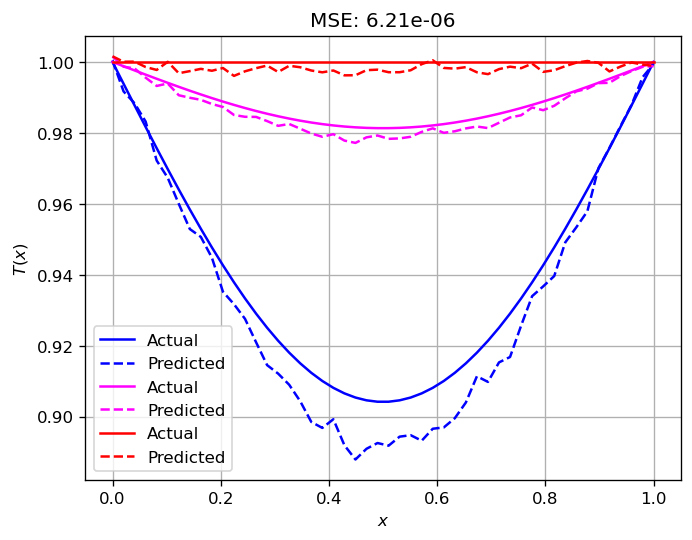

In [38]:
# now test the model on solutions obtained for the heat equation with another thermal diffusivity (a below)

a = 4.0 # thermal diffusivity

Nx = 50
x, dx = np.linspace(0, 1, Nx, retstep = True)
initial_temp = np.cos(np.pi*x)**2# some simple initial temperature that respects the boundary conditions
solutions_a = [initial_temp] # store the initial condition as the solution at t = 0
Nt = 100
t_end = 0.5
times, dt = np.linspace(0, t_end, Nt, retstep = True)
D2 = diags([1, -2, 1], offsets=[-1, 0, 1], shape=(Nx, Nx), format='csr') / dx**2 # second derivative matrix
A = eye(Nx, format='csr') - a * dt * D2 # matrix for equation to be solved in implicit Euler
# enforce the boundary conditions directly in the matrix
A = A.tolil()
A[0, :] = 0;  A[0, 0] = 1; A[-1, :] = 0; A[-1, -1] = 1
A = A.tocsr()

# now let the system evolve. if we use explicit Euler for stability we need the CFL condition 
# so to get around this issue we use implicit Euler
for k in range(Nt):
    solutions_a.append(spsolve(A, solutions_a[-1]))


# now apply an RNN to the solutions  
# first, format the data for the RNN
window_size = 12

solution_intervals_a = [] # ensemble of the solution vectors 
targets_a = [] # the solution to be predicted, i.e. the one after each window

for i in range(Nt - window_size):
    solution_intervals_a.append(solutions_a[i:i+window_size])
    targets_a.append(solutions_a[i + window_size])  # what we want to predict

# Convert to PyTorch tensors with shapes: (Batch, Seq_Len, Features)
# use unsqueeze so that the RNN sees each time values as a vector of size 1 (and not as a scalar)
solution_intervals_a_tensor = torch.tensor(np.array(solution_intervals_a), dtype=torch.float32)
targets_tensor_a            = torch.tensor(np.array(targets_a), dtype=torch.float32)

model.eval() # sets the model to inference mode
# do a bunch of predictions 
with torch.no_grad(): # torch.no_grad disables gradient computation, so the nn will not be changed during the forward pass
    # Pick a window from the solution and predict the next frame
    test_input_a = solution_intervals_a_tensor[:]  # (1, window_size, Nx).  start:finish 
    predicted_a  = model(test_input_a).squeeze(0).numpy() # apply the model to the input and get a prediction
    actual_a     = targets_tensor_a[:].numpy() # indeed, the target to reproduce



# plot some of the predictions
plt.figure(dpi = 120)
plt.plot(x, actual_a[0],    label="Actual", color = 'blue')
plt.plot(x, predicted_a[0], label="Predicted", linestyle='--', color = 'blue')
plt.plot(x, actual_a[9],    label="Actual", color = 'magenta')
plt.plot(x, predicted_a[9], label="Predicted", linestyle='--', color = 'magenta')
plt.plot(x, actual_a[-1],    label="Actual", color = 'red')
plt.plot(x, predicted_a[-1], label="Predicted", linestyle='--', color = 'red')
plt.xlabel("$x$"); plt.ylabel("$T(x)$")
plt.title(f"MSE: {np.mean((predicted_a - actual_a)**2):.2e}")
#plt.ylim((0,1))
plt.legend(); plt.grid(); plt.show()

# **WOULD BE GOOD TO DO**: train on more diverse dataset composed of simulations obtained with different values of a (thermal diffusivity)

- at least use such a second dataset as eval dataset during training